In [34]:
# ─── 1. Imports & Setup ───
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pycocotools.coco import COCO
import skimage.io as io
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
%matplotlib inline

In [16]:
# ─── 2. Mount Drive & Unzip Dataset ───
from google.colab import drive
drive.mount("/content/drive")

!unzip -q "/content/drive/MyDrive/RM_Segmentation_Assignment_dataset.zip" \
       -d "/content/drive/MyDrive/coco2017/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/drive/MyDrive/coco2017/test-30/000000001751.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [17]:
# ─── 3. Load COCO Annotations ───
train_data_path = "/content/drive/MyDrive/coco2017/train-300"
train_annotation_file = os.path.join(train_data_path, "labels.json")
coco = COCO(train_annotation_file)


loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


In [18]:
# ─── 4. Explore Categories & Supercategories ───
cat_ids_all = coco.getCatIds()
cats = coco.loadCats(cat_ids_all)
print("COCO categories ({}):".format(len(cats)),
      ", ".join([c["name"] for c in cats]))
supercats = sorted({c["supercategory"] for c in cats})
print("Supercategories ({}):".format(len(supercats)), ", ".join(supercats))

# Utility: category name lookup
def get_category_name(cat_id):
    for c in cats:
        if c["id"] == cat_id:
            return c["name"]
    return None

# Sample category name lookups
for test_id in [10, 0, 15, 18, 25, 41, 58, 62, 16]:
    print(f"Category name for ID {test_id}: {get_category_name(test_id)}")

COCO categories (63): airplane, backpack, banana, baseball bat, baseball glove, bear, bench, bicycle, bird, boat, book, bottle, bowl, broccoli, bus, cake, car, carrot, cat, cell phone, chair, clock, cow, cup, dining table, dog, donut, elephant, fire hydrant, fork, frisbee, giraffe, handbag, horse, hot dog, kite, knife, laptop, motorcycle, oven, parking meter, person, pizza, potted plant, refrigerator, remote, sandwich, scissors, skateboard, skis, spoon, sports ball, stop sign, suitcase, surfboard, tennis racket, tie, traffic light, train, truck, umbrella, vase, wine glass
Supercategories (12): accessory, animal, appliance, electronic, food, furniture, indoor, kitchen, outdoor, person, sports, vehicle
Category name for ID 10: book
Category name for ID 0: airplane
Category name for ID 15: cake
Category name for ID 18: cat
Category name for ID 25: dog
Category name for ID 41: person
Category name for ID 58: train
Category name for ID 62: wine glass
Category name for ID 16: car


In [19]:
# ─── 5. Select Target Classes & Image Lists ───
target_classes = ["cake", "car", "dog", "person"]
target_cat_ids = coco.getCatIds(catNms=target_classes)

# Per-class image counts and IDs
for cls in target_classes:
    ids = coco.getImgIds(catIds=coco.getCatIds(catNms=[cls]))
    print(f"{cls}: {len(ids)} images, sample IDs = {ids[:5]}")

# Load all unique images containing at least one target object
all_images = []
for cls in target_classes:
    for img_info in coco.loadImgs(coco.getImgIds(catIds=coco.getCatIds(catNms=[cls]))):
        all_images.append(img_info)
# Remove duplicates
unique_images = {img["id"]: img for img in all_images}.values()
unique_images = list(unique_images)
print("Unique images containing target classes:", len(unique_images))
random.seed(0)
random.shuffle(unique_images)

cake: 1 images, sample IDs = [240]
car: 283 images, sample IDs = [1, 2, 3, 4, 5]
dog: 10 images, sample IDs = [32, 225, 261, 71, 169]
person: 272 images, sample IDs = [1, 2, 3, 4, 5]
Unique images containing target classes: 300


Sample image info: {'id': 99, 'file_name': '000000007124.jpg', 'height': 426, 'width': 640, 'license': None, 'coco_url': None}
Annotations for this image:
- cat_id=41 (person), bbox=[402.16999999999996, 1.05, 237.83, 424.95], segmentation present
- cat_id=16 (car), bbox=[297.87, 84.37, 57.38, 39.31], segmentation present


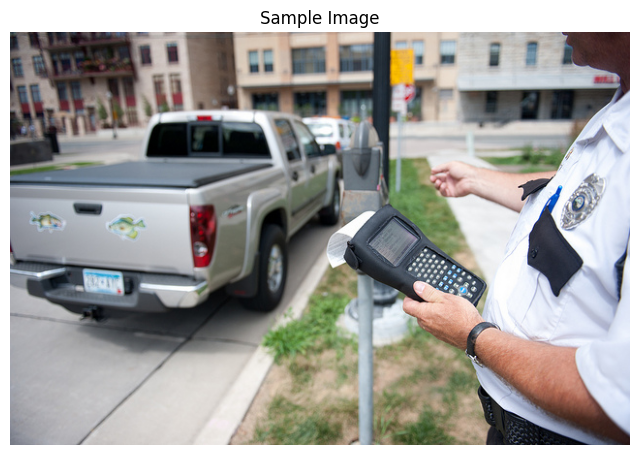

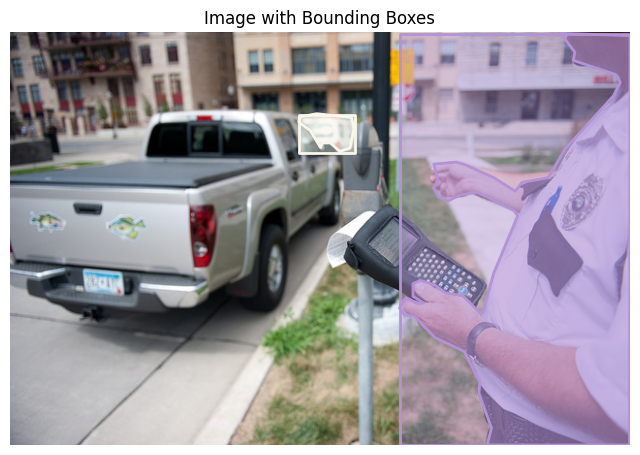

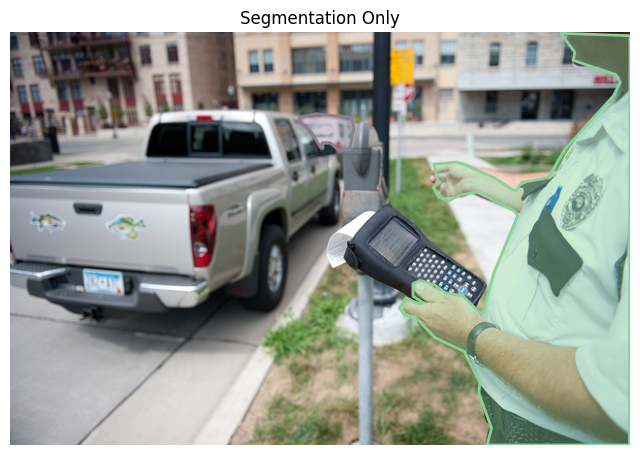

Mask example: type <class 'numpy.ndarray'> shape (426, 640) min/max 0 / 1


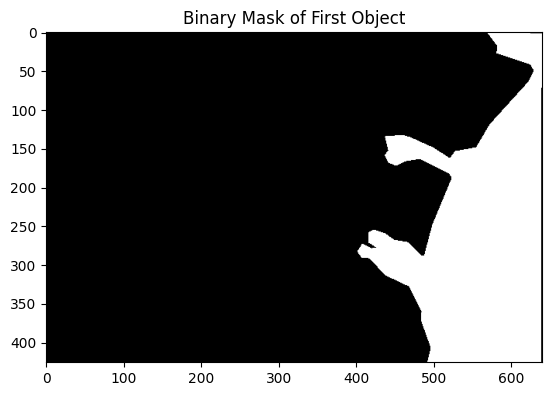

In [20]:
# ─── 6. Display One Sample Image + Annotations ───
sample = unique_images[0]
print("Sample image info:", sample)
img = io.imread(os.path.join(train_data_path, "data", sample["file_name"]))
plt.figure(figsize=(8,6))
plt.axis("off")
plt.imshow(img)
plt.title("Sample Image")

# Load & show annotations
ann_ids = coco.getAnnIds(imgIds=sample["id"], catIds=target_cat_ids, iscrowd=None)
anns = coco.loadAnns(ann_ids)
print("Annotations for this image:")
for ann in anns:
    print(f"- cat_id={ann['category_id']} "
          f"({get_category_name(ann['category_id'])}), bbox={ann['bbox']}, "
          f"{'segmentation N/A' if 'segmentation' not in ann else 'segmentation present'}")

# Image with Bounding Boxes
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
coco.showAnns(anns, draw_bbox=True)
plt.title("Image with Bounding Boxes")
plt.show()

# Segmentation Only
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
coco.showAnns(anns, draw_bbox=False)
plt.title("Segmentation Only")
plt.show()

# Explore annToMask output
mask_example = coco.annToMask(anns[0])
print("Mask example: type", type(mask_example),
      "shape", mask_example.shape,
      "min/max", mask_example.min(), "/", mask_example.max())
plt.imshow(mask_example, cmap="gray")
plt.title("Binary Mask of First Object")
plt.show()


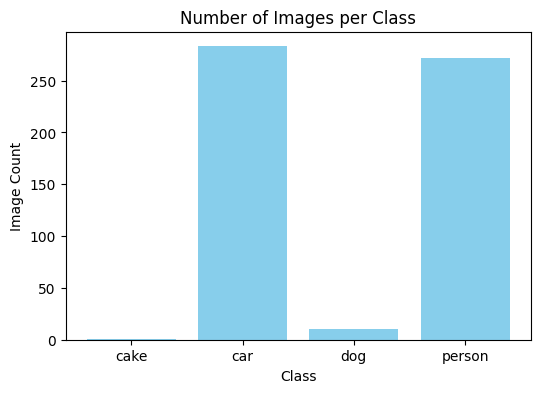

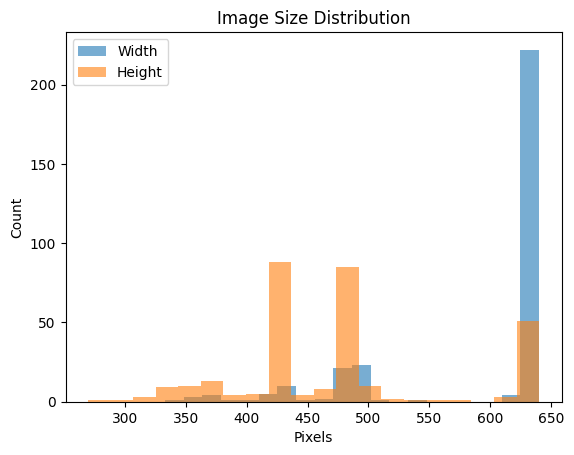

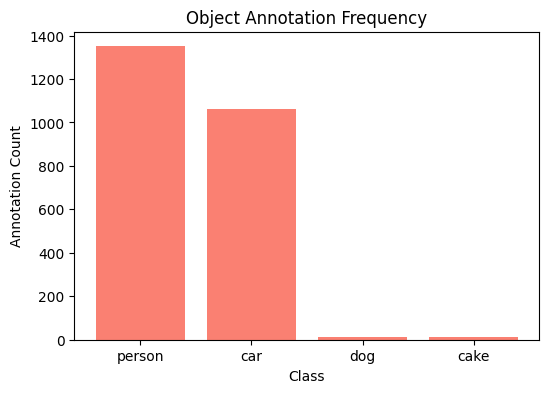

In [21]:
# ─── 7. Dataset EDA ───
# Image count per class
image_counts = {cls: len(coco.getImgIds(catIds=coco.getCatIds(catNms=[cls])))
                for cls in target_classes}
plt.figure(figsize=(6,4))
plt.bar(image_counts.keys(), image_counts.values(), color="skyblue")
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.show()

# Image size distribution
sizes = np.array([(img["width"], img["height"]) for img in unique_images])
plt.hist(sizes[:, 0], bins=20, alpha=0.6, label="Width")
plt.hist(sizes[:, 1], bins=20, alpha=0.6, label="Height")
plt.title("Image Size Distribution")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.show()

# Object annotation frequency
ann_ids_all = coco.getAnnIds(imgIds=[img["id"] for img in unique_images],
                             catIds=target_cat_ids)
anns_all = coco.loadAnns(ann_ids_all)
freq = Counter([get_category_name(a["category_id"]) for a in anns_all])
plt.figure(figsize=(6,4))
plt.bar(freq.keys(), freq.values(), color="salmon")
plt.title("Object Annotation Frequency")
plt.xlabel("Class")
plt.ylabel("Annotation Count")
plt.show()

In [22]:
# ─── 8. Mask Creation ───
def create_mask(img_info):
    mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
    for ann in coco.loadAnns(coco.getAnnIds(imgIds=[img_info["id"]],
                                              catIds=target_cat_ids)):
        idx = target_cat_ids.index(ann["category_id"]) + 1
        mask = np.maximum(mask, coco.annToMask(ann) * idx)
    return mask

In [23]:
# ─── 9. Data Augmentation ───
def augment_image_and_mask(image, mask):
    # Random horizontal flip
    if random.random() > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
    # Random vertical flip
    if random.random() > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)
    # Random rotation by k*90 degrees
    k = random.choice([0, 1, 2, 3])
    image = tf.image.rot90(image, k=k)
    mask = tf.image.rot90(mask, k=k)
    return image, mask

In [24]:
# ─── 10. Preprocessing with Augmentation Option ───
def preprocess_data(img_list, size=(128,128), augment=False):
    imgs, masks = [], []
    for imf in img_list:
        try:
            img = io.imread(os.path.join(train_data_path, "data", imf["file_name"]))
            mask = create_mask(imf)
            img = tf.image.resize(img, size) / 255.0
            mask = tf.image.resize(tf.expand_dims(mask, -1), size, method="nearest")
            if augment:
                img, mask = augment_image_and_mask(img, mask)
            imgs.append(img.numpy())
            masks.append(mask.numpy().squeeze())
        except Exception as e:
            print("Skipping", imf["file_name"], "due to", str(e))
    return np.array(imgs), np.array(masks)

train_imgs, val_imgs = train_test_split(unique_images,
                                        test_size=0.2,
                                        random_state=42)
X_train, y_train = preprocess_data(train_imgs, augment=True)
X_val, y_val = preprocess_data(val_imgs, augment=False)

print("Shapes:", X_train.shape, y_train.shape)

Skipping 000000000821.jpg due to 'images' must have either 3 or 4 dimensions.
Skipping 000000005294.jpg due to 'images' must have either 3 or 4 dimensions.
Shapes: (239, 128, 128, 3) (239, 128, 128)


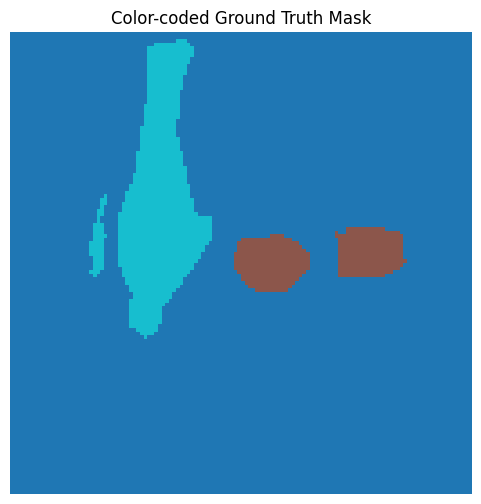

In [25]:
# ─── 11. Visualize Color-Mapped Mask ───
def colorize_mask(mask):
    cmap = plt.get_cmap("tab10")
    out = cmap(mask / (mask.max() or 1))
    return out

plt.figure(figsize=(6,6))
plt.imshow(colorize_mask(y_train[0]))
plt.title("Color-coded Ground Truth Mask")
plt.axis("off")
plt.show()

In [26]:
# ─── 12. Define IoU Metric for Evaluation and Weighted Loss Function ───
def iou_coef(y_true, y_pred, num_classes=len(target_classes)+1, smooth=1e-6):
    y_true = tf.one_hot(tf.cast(tf.squeeze(y_true), tf.int32), num_classes)
    y_pred = tf.one_hot(tf.argmax(y_pred, axis=-1), num_classes)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[0,1,2])
    union = tf.reduce_sum(y_true + y_pred, axis=[0,1,2]) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return tf.reduce_mean(iou)

class_weights = tf.constant([0.1, 1.0, 1.0, 1.0, 1.0])

def weighted_sparse_cce(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_true_one_hot = tf.one_hot(y_true, depth=5)
    weights = tf.reduce_sum(class_weights * y_true_one_hot, axis=-1)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return loss * weights

In [27]:
# ─── 13. U-Net Model ───
def unet_model(input_size=(128,128,3), num_classes=len(target_classes)+1):
    inputs = layers.Input(input_size)
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(64, 3, activation="relu", padding="same")(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(64, 3, activation="relu", padding="same")(c3)
    c3 = layers.BatchNormalization()(c3)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(32, 3, activation="relu", padding="same")(u1)
    c4 = layers.BatchNormalization()(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(16, 3, activation="relu", padding="same")(u2)
    c5 = layers.BatchNormalization()(c5)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c5)
    return models.Model(inputs, outputs)

model = unet_model()
model.compile(optimizer="adam",
              loss=weighted_sparse_cce,
              metrics=["accuracy", iou_coef])


In [28]:
# ─── 14. Train ───
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10, batch_size=8)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.2326 - iou_coef: 0.0691 - loss: 0.3837 - val_accuracy: 0.1035 - val_iou_coef: 0.0240 - val_loss: 0.3217
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3586 - iou_coef: 0.1029 - loss: 0.2965 - val_accuracy: 0.7340 - val_iou_coef: 0.1471 - val_loss: 0.3386
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4356 - iou_coef: 0.1240 - loss: 0.2954 - val_accuracy: 0.8937 - val_iou_coef: 0.1783 - val_loss: 0.3964
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.4724 - iou_coef: 0.1294 - loss: 0.2862 - val_accuracy: 0.8879 - val_iou_coef: 0.1771 - val_loss: 0.4241
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5104 - iou_coef: 0.1541 - loss: 0.2716 - val_accuracy: 0.8974 - val_iou_coef: 0.5290 - val_loss: 0.4478
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.4866 - iou_coef: 0.2498 - loss: 0.2605 - val_accuracy: 0.8946 - val_iou_coef: 0.5293 - val_loss:

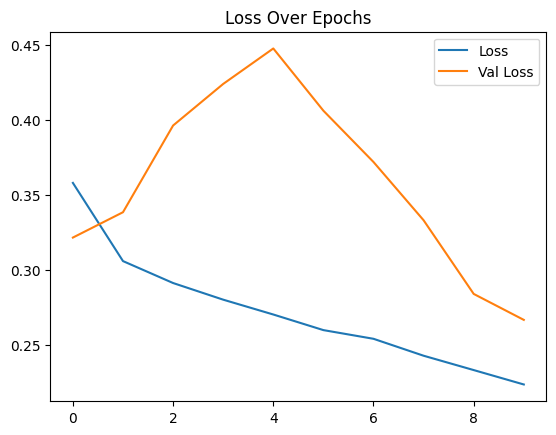

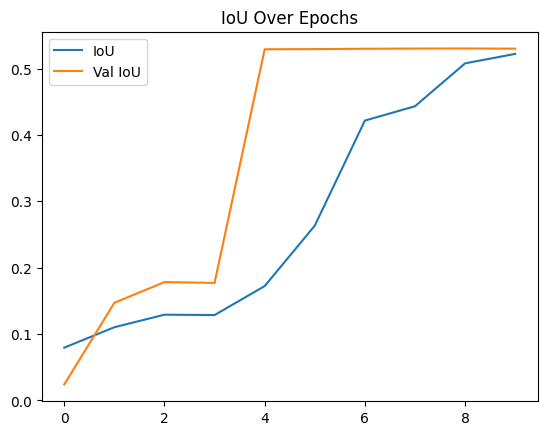

In [29]:
# ─── 15. Visualize Metrics ───
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.show()

plt.plot(history.history['iou_coef'], label='IoU')
plt.plot(history.history['val_iou_coef'], label='Val IoU')
plt.title('IoU Over Epochs')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


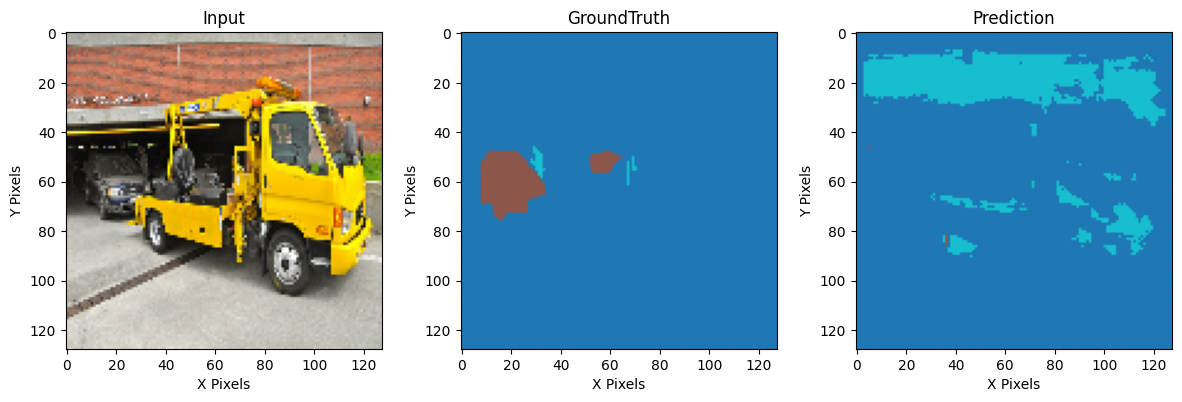

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


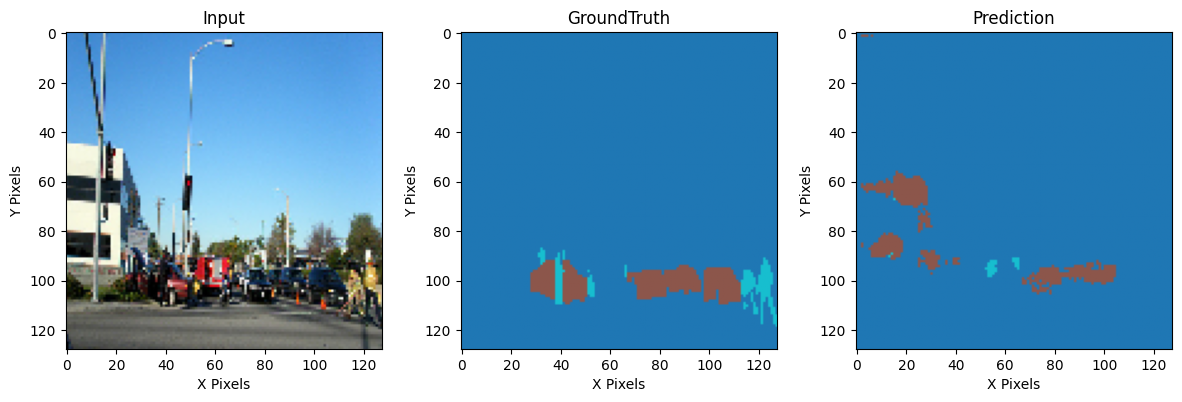

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


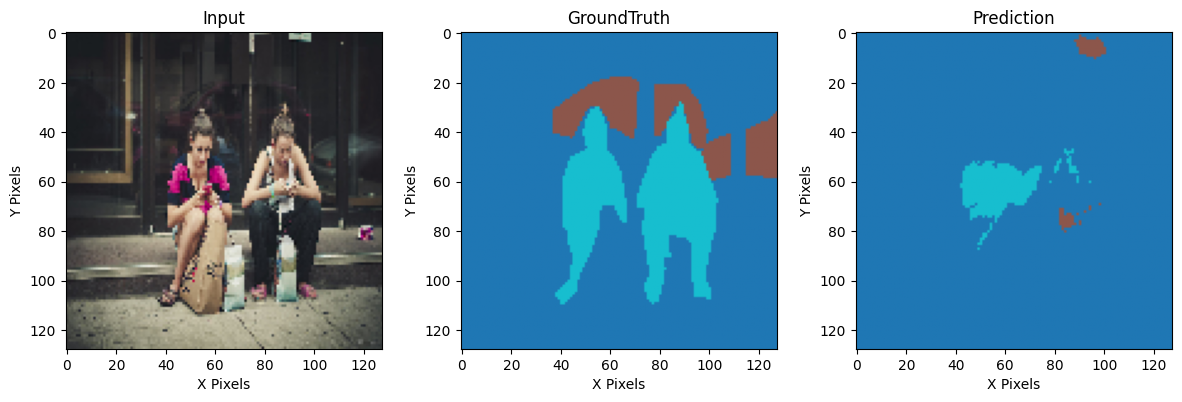

In [33]:
  # ─── 16. Predictions & Visual Comparison ───
for i in range(3):
    img = X_val[i]
    gt = y_val[i]
    pred = np.argmax(model.predict(tf.expand_dims(img, 0))[0], axis=-1)
    plt.figure(figsize=(12,4))
    for j, (d, ttl) in enumerate(zip([img, gt, pred], ["Input", "GroundTruth", "Prediction"])):
        plt.subplot(1, 3, j+1)
        plt.imshow(d if j == 0 else colorize_mask(d))
        plt.title(ttl)
        plt.xlabel("X Pixels"); plt.ylabel("Y Pixels")
        plt.axis("on")
    plt.tight_layout()
    plt.show()

In [31]:
# ─── 17. Per-Class IoU ───
def per_class_iou(y_true, y_pred, num_classes=len(target_classes)+1, smooth=1e-6):
    ious = []
    for cls in range(num_classes):
        true_cls = (y_true == cls).astype(np.int32)
        pred_cls = (y_pred == cls).astype(np.int32)
        intersection = np.sum(true_cls * pred_cls)
        union = np.sum(true_cls) + np.sum(pred_cls) - intersection
        iou = (intersection + smooth) / (union + smooth)
        ious.append(iou)
    return ious

label_names = ["BG"] + target_classes
ious_all = []
for i in range(len(X_val)):
    true_mask = y_val[i]
    pred_mask = np.argmax(model.predict(tf.expand_dims(X_val[i], 0))[0], axis=-1)
    ious = per_class_iou(true_mask, pred_mask)
    ious_all.append(ious)

mean_ious = np.mean(ious_all, axis=0)
for cls_id, iou_score in enumerate(mean_ious):
    print(f"{label_names[cls_id]}: {iou_score:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


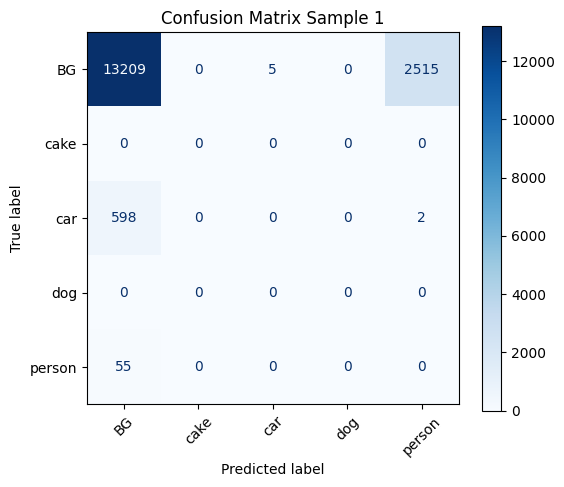

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


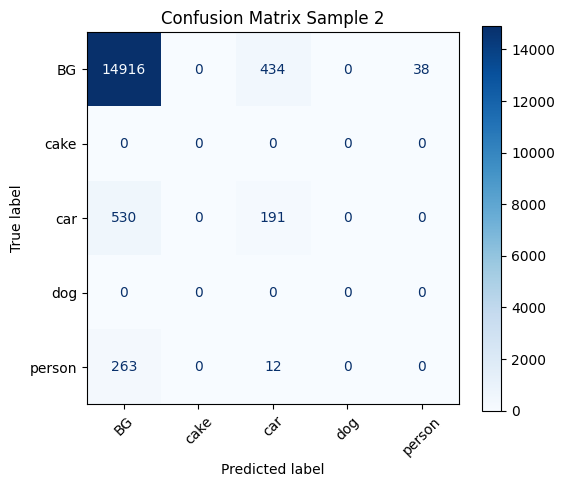

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


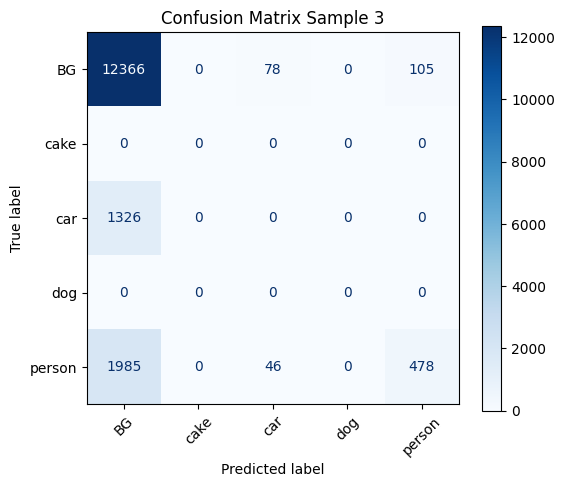

In [32]:
# ─── 18. Confusion Matrices ───
for i in range(3):
    true = y_val[i].flatten()
    pred = np.argmax(model.predict(tf.expand_dims(X_val[i], 0))[0], axis=-1).flatten()
    cm = confusion_matrix(true, pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    plt.figure(figsize=(6,5))
    disp.plot(cmap="Blues", xticks_rotation=45, ax=plt.gca())
    plt.title(f"Confusion Matrix Sample {i+1}")
    plt.show()